## Flight Delays and Cancellations Analysis
In this notebook, we analyze flight cancellation rates across different airlines and routes in Australia.
The goal is to identify patterns and provide booking recommendations.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving otp_top5_routes.csv to otp_top5_routes.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("otp_top5_routes.csv")
df.head()

,Route,Departing_Port,Arriving_Port,Airline,Month,Sectors_Scheduled,Sectors_Flown,Cancellations,Departures_On_Time,Arrivals_On_Time,Departures_Delayed,Arrivals_Delayed,Year,Month_Num
0,Brisbane-Melbourne,Brisbane,Melbourne,Qantas,2004-01-01,496.0,492,4.0,410.0,427.0,82.0,65.0,2004,1
1,Brisbane-Sydney,Brisbane,Sydney,Qantas,2004-01-01,683.0,677,6.0,576.0,595.0,101.0,82.0,2004,1
2,Melbourne-Sydney,Melbourne,Sydney,Qantas,2004-01-01,821.0,799,22.0,723.0,706.0,76.0,93.0,2004,1
3,Sydney-Brisbane,Sydney,Brisbane,Qantas,2004-01-01,686.0,682,4.0,614.0,599.0,68.0,83.0,2004,1
4,Sydney-Melbourne,Sydney,Melbourne,Qantas,2004-01-01,800.0,785,15.0,683.0,708.0,102.0,77.0,2004,1


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4260 entries, 0 to 4259
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Route               4260 non-null   object 
 1   Departing_Port      4260 non-null   object 
 2   Arriving_Port       4260 non-null   object 
 3   Airline             4260 non-null   object 
 4   Month               4260 non-null   object 
 5   Sectors_Scheduled   4260 non-null   float64
 6   Sectors_Flown       4260 non-null   int64  
 7   Cancellations       4260 non-null   float64
 8   Departures_On_Time  4260 non-null   float64
 9   Arrivals_On_Time    4260 non-null   float64
 10  Departures_Delayed  4260 non-null   float64
 11  Arrivals_Delayed    4260 non-null   float64
 12  Year                4260 non-null   int64  
 13  Month_Num           4260 non-null   int64  
 14  Cancellation_Rate   4255 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 499.3+

In [56]:
df.describe()

,Sectors_Scheduled,Sectors_Flown,Cancellations,Departures_On_Time,Arrivals_On_Time,Departures_Delayed,Arrivals_Delayed,Year,Month_Num,Cancellation_Rate
count,4260.000000,4260.000000,4260.000000,4260.000000,4260.000000,4260.000000,4260.000000,4260.000000,4260.000000,4255.000000
mean,415.460094,397.374178,18.085915,321.504550,313.039917,75.869629,84.334261,2015.039437,6.420188,0.048594
std,283.489991,271.988554,28.237124,231.996657,223.064710,60.454950,69.863671,5.550921,3.444248,0.092377
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2004.000000,1.000000,0.000000
25%,150.000000,142.000000,3.000000,103.000000,104.000000,31.000000,32.000000,2011.000000,3.000000,0.012346
50%,394.500000,377.000000,9.000000,295.500000,286.500000,62.000000,66.000000,2015.000000,6.000000,0.027184
75%,619.250000,604.000000,22.000000,502.000000,485.000000,106.000000,121.000000,2019.000000,9.000000,0.050000
max,1151.000000,1072.000000,494.000000,938.000000,934.000000,416.000000,448.000000,2024.000000,12.000000,1.000000


### 1. Distribution of Cancellation Rates
We calculate the cancellation rate for each flight by dividing cancellations by scheduled sectors.
Then we visualize the distribution to understand how cancellations are spread across all flights.

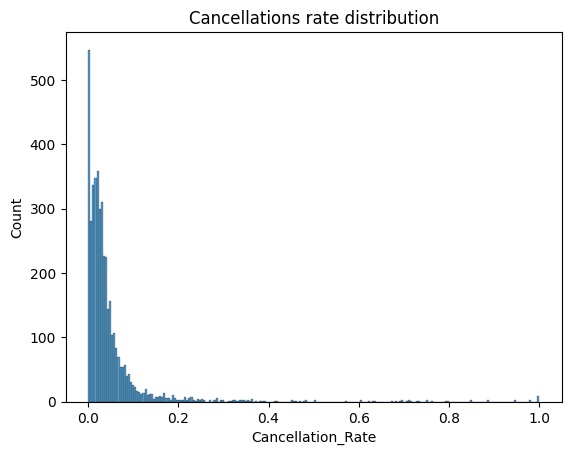

In [13]:
# Find the proportion of cancelled flights (divide cancellations by the scheduled flights)
df["Cancellation_Rate"] = df["Cancellations"] / df["Sectors_Scheduled"]

# Plot the histogram
sns.histplot(data=df, x="Cancellation_Rate")
plt.xlabel("Cancellation_Rate")
plt.title("Cancellations rate distribution")
plt.show()

In [17]:
print("Mean:", df["Cancellation_Rate"].mean())
print("Median:", df["Cancellation_Rate"].median())


Mean: 0.04859444572410242
Median: 0.027184466019417475


**Conclusion:** The distribution is right-skewed. Most flights have a cancellation rate below 10%,
but a small number of flights have very high cancellation rates, creating a long tail.
The median (2.7%) is a better measure than the mean (4.9%) due to the presence of outliers.

### 2. Boxplot of Cancellation Rates
A boxplot provides a concise summary of the distribution, showing the median, spread, and outliers.

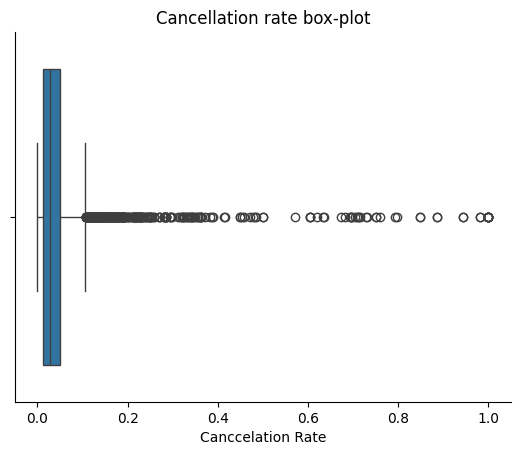

In [25]:
# Create the box plot
sns.boxplot(data=df, x="Cancellation_Rate")
plt.xlabel("Canccelation Rate")
plt.title("Cancellation rate box-plot")
sns.despine()
plt.show()

The distribution of cancellation rates is right-skewed (positively skewed). The majority of flights have a cancellation rate below 10%, with a median of 2.7%. However, the mean is 4.9%, which is higher than the median, indicating the presence of a small number of flights with very high cancellation rates. These outliers pull the mean upward and create a long tail in the distribution.

**The median is a better measure of central tendency than the mean for this dataset, due to the presence of outliers.**

### 3. Cancellation Rates by Airline
We compare cancellation rates across different airlines to identify which ones are most reliable.

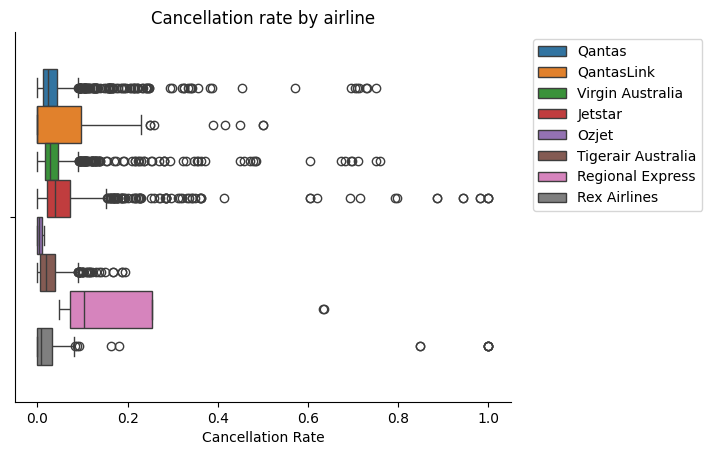

In [40]:
# Creat the box-plot use hue to separate by airline
sns.boxplot(data=df, x="Cancellation_Rate", hue="Airline")
plt.xlabel("Cancellation Rate")
plt.title("Cancellation rate by airline")
plt.legend(loc="upper right" , bbox_to_anchor=(1.4, 1))
sns.despine()
plt.show()

In [44]:
df.groupby("Airline")["Cancellation_Rate"].median().sort_values(ascending=False)

,Cancellation_Rate
Airline,
Regional Express,0.104321
Jetstar,0.040000
Virgin Australia,0.028653
Qantas,0.024116
Tigerair Australia,0.018692
Rex Airlines,0.008772
Ozjet,0.003759
QantasLink,0.000000


**Regional Express** has the highest median cancellation rate at **10.4%**, while **Rex Airlines** and **Jetstar** show the largest outliers, reaching up to **100%** cancellation on rare occasions. **QantasLink** is the most reliable airline with a median cancellation rate of **0%**.

### 4. Cancellation Rates by Route and Month
A heatmap allows us to identify seasonal patterns and which routes are most affected by cancellations.

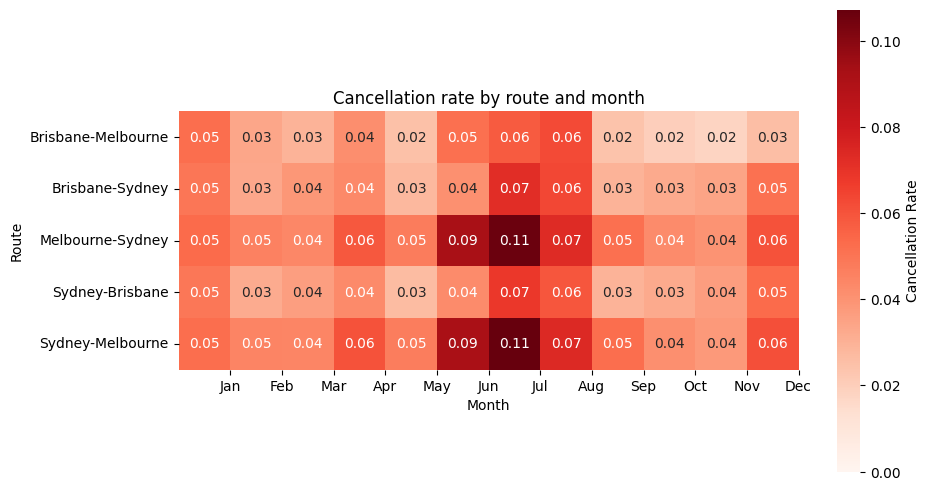

In [53]:
heatmap_data = df.pivot_table(index="Route",
                              columns="Month_Num",
                              values="Cancellation_Rate",
                              aggfunc="mean")
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data,
            annot=True,
            fmt=".2f",
            cmap="Reds",
            cbar_kws={"label": "Cancellation Rate"},
            vmin=0,
            square=True)
plt.title("Cancellation rate by route and month")
plt.xlabel("Month")
plt.xticks(ticks=range(1,13), labels=[
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.show()

Cancellation rates peak in **June** and **July**, particularly on the **Melbourne-Sydney** route, likely due to winter weather conditions. **January** and **February** show the lowest cancellation rates across all routes.